In [233]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import operator


In [234]:
# generator_llm = ChatGroq(model="openai/gpt-oss-20b")
generator_llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
evaluator_llm = ChatGroq(model="llama-3.3-70b-versatile")
optimisation_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [235]:
from pydantic import BaseModel,Field

class TweetEvaluation(BaseModel):
    evaluation : Literal["approved","needs_improvement"] = Field(description="Final evaluation result")
    feedback : str = Field(description="Feedback for improving the tweet")

In [ ]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [237]:
class TweetState(TypedDict):

    topic : str
    tweet : str
    evaluation : Literal["approved","needs_improvement"]
    feedback : str
    iteration : int
    max_iterations : int
    tweet_history : Annotated[list[str], operator.add]
    feedback_history : Annotated[list[str], operator.add]

In [238]:
def generate_tweet(state: TweetState) -> TweetState:

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]


    # send to llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}



In [239]:
def evaluate_tweet(state: TweetState) -> TweetState:

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
    ]


    # send to llm
    response = structured_evaluator_llm.invoke(messages)


    # return response
    return {
        'evaluation': response.evaluation,
        'feedback': response.feedback,
        'feedback_history': [response.feedback]
    }

In [240]:
def optimise_tweet(state: TweetState) -> TweetState:

    # prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    # send to llm
    response = optimisation_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    # return response
    return {
        'tweet': response,
        'iteration': iteration,
        'tweet_history': [response]
    }

In [241]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

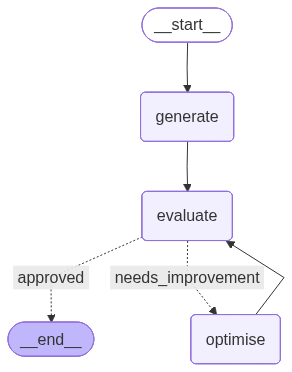

In [242]:
graph = StateGraph(TweetState)

# create Node
graph.add_node("generate", generate_tweet)
graph.add_node("evaluate", evaluate_tweet)
graph.add_node("optimise", optimise_tweet)



# create edges
graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")
graph.add_conditional_edges("evaluate", route_evaluation,{"approved": END, "needs_improvement": "optimise" })
graph.add_edge("optimise", "evaluate")


# compile graph
workflow = graph.compile()
workflow




In [243]:
# execute graph
initial_state = {
    'topic': "Indian Railways",
    'iteration': 1,
    'max_iterations': 5,
    'tweet_history': [],
    'feedback_history': []
}

workflow.invoke(initial_state)


{'topic': 'Indian Railways',
 'tweet': '"Just boarded the Indian Railways express... said no one ever! \'Delayed by 2 hours\' is just a suggestion, right? Meanwhile, chaiwala\'s on schedule, selling tea at platform 3 #IndianRailways #TrainLife"',
 'evaluation': 'approved',
 'feedback': "This tweet is a great example of a well-crafted joke that meets all the criteria. It's original, humorous, and punchy, with a clever play on the common experience of delayed trains in India. The use of the hashtag #IndianRailways and #TrainLife adds to its virality potential, and the format is well-suited for a tweet, being concise and under 280 characters. The tweet effectively uses wordplay and sarcasm to make a point, and the reference to the 'chaiwala' adds a relatable and amusing touch. Overall, this tweet has a high chance of making readers smile and being shared, which is why it's approved.",
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['"Just boarded the Indian Railways express... s

In [247]:
# execute graph
initial_state = {
    'topic': "chilgoja",
    'iteration': 1,
    'max_iterations': 5,
    'tweet_history': [],
    'feedback_history': []
}

result = workflow.invoke(initial_state)


In [248]:
result

{'topic': 'chilgoja',
 'tweet': '"just spent 20 mins cracking open a chilgoja (peanut) and I think I\'ve earned a PhD in shell-ebration. Who needs therapy when you have chilgoja-induced frustration?" #chilgojalife #nuttyproblems',
 'evaluation': 'approved',
 'feedback': "This tweet is a masterclass in crafting a humorous and engaging post. The use of wordplay with 'shell-ebration' and 'chilgoja-induced frustration' is original and clever, making it stand out from the usual mundane tweets. The humor is spot on, with a lighthearted and relatable tone that will likely make readers smile. The punchiness is also effective, with a short and sharp message that grabs attention. The tweet's format is well-formed, and the hashtags #chilgojalife and #nuttyproblems add a touch of personality to the post. Overall, this tweet has great virality potential, and its unique blend of humor and creativity makes it a compelling read.",
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['"just spent 

In [249]:
for tweet, feedback in zip(result['tweet_history'], result['feedback_history']):
    print(f"Tweet: {tweet}\nFeedback: {feedback}\n{'-'*50}\n")

Tweet: "just spent 20 mins cracking open a chilgoja (peanut) and I think I've earned a PhD in shell-ebration. Who needs therapy when you have chilgoja-induced frustration?" #chilgojalife #nuttyproblems
Feedback: This tweet is a masterclass in crafting a humorous and engaging post. The use of wordplay with 'shell-ebration' and 'chilgoja-induced frustration' is original and clever, making it stand out from the usual mundane tweets. The humor is spot on, with a lighthearted and relatable tone that will likely make readers smile. The punchiness is also effective, with a short and sharp message that grabs attention. The tweet's format is well-formed, and the hashtags #chilgojalife and #nuttyproblems add a touch of personality to the post. Overall, this tweet has great virality potential, and its unique blend of humor and creativity makes it a compelling read.
--------------------------------------------------

